# Stock Market Prices Prediction with Long short term memory(LSTM)

__LSTM (Long Short-Term Memory)__ model on a stock market dataset is a common approach for time series forecasting, such as predicting future stock prices. We'll conduct few data cleaning, data transformation and Exploratory data analysis then after we'll build, train, and evaluate an LSTM model using Python and TensorFlow/Keras.

### About Dataset

Title: Stock Prices of 500 Biggest Companies by Market Cap (Last 5 Years)

### Description:
This dataset comprises historical stock market data extracted from Yahoo Finance, spanning a period of five years. It includes daily records of stock performance metrics for the top 500 companies based on market capitalization.

#### Attributes:

- Date: The date corresponding to the recorded stock market data.
- Open: The opening price of the stock on a given date.
- High: The highest price of the stock reached during the trading day.
- Low: The lowest price of the stock observed during the trading day.
- Close: The closing price of the stock on a specific date.
- Volume: The volume of shares traded on the given date.
- Dividends: Any dividend payments made by the company on that date (if applicable).
- Stock Splits: Information regarding any stock splits occurring on that date.
- Company: Ticker symbol or identifier representing the respective company.

## Load python necessary libreries

In [1]:
# You can also use this section to suppress warnings generated by your code:

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential, Model
# For time stamps
from datetime import datetime
from sklearn.metrics import precision_recall_fscore_support
from keras import initializers
from tensorflow.keras.layers import SimpleRNN, Dense,LSTM
from tensorflow.keras.optimizers import Adam


2025-10-10 10:04:12.710276: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760090652.902439      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760090652.960087      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Read the dataset

After loading the stock market dataset, we will filter it to include only the top six companies: `Apple, Microsoft, Google, Amazon, Meta, and Tesla.` Then, we'll standardize the company names by correcting their spelling and formatting

In [3]:
finance = pd.read_csv("/kaggle/input/massive-yahoo-finance-dataset/stock_details_5_years.csv")

company_list = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA']
company_name = ['Apple', 'Microsoft', 'Google', 'Amazon', 'Meta', 'Tesla']
#Filter the dataset to the above companies's list

filtered_data = []
for company, com_name in zip(company_list, company_name):
    company_data = finance[finance['Company'] == company].copy()
    company_data['company_name'] = com_name
    filtered_data.append(company_data)
    filtered_data[-1] = filtered_data[-1].drop(columns=['Company', 'Stock Splits'])
#concatenate all filtered data

data = pd.concat(filtered_data, axis=0)


We'll to convert the 'Date' column to datetime format.


In [4]:
#pd.to_datetime(arg, errors='raise', dayfirst=False, yearfirst=False, utc=False, format=None, exact=True, unit=None, infer_datetime_format=False)
data['Date'] = pd.to_datetime(data['Date'], utc=True, errors='coerce')

#Extract various date related features
#data['quarter'] = data['Date'].dt.quarter
data['year'] = data['Date'].dt.year
#data['month'] = data['Date'].dt.strftime('%B')


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7548 entries, 0 to 602476
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   Date          7548 non-null   datetime64[ns, UTC]
 1   Open          7548 non-null   float64            
 2   High          7548 non-null   float64            
 3   Low           7548 non-null   float64            
 4   Close         7548 non-null   float64            
 5   Volume        7548 non-null   int64              
 6   Dividends     7548 non-null   float64            
 7   company_name  7548 non-null   object             
 8   year          7548 non-null   int32              
dtypes: datetime64[ns, UTC](1), float64(5), int32(1), int64(1), object(1)
memory usage: 560.2+ KB


In [6]:
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,company_name,year
0,2018-11-29 05:00:00+00:00,43.829761,43.863354,42.639594,43.083508,167080000,0.0,Apple,2018
458,2018-11-30 05:00:00+00:00,43.261071,43.270671,42.478826,42.850754,158126000,0.0,Apple,2018
916,2018-12-03 05:00:00+00:00,44.261681,44.376858,43.481835,44.348064,163210000,0.0,Apple,2018
1374,2018-12-04 05:00:00+00:00,43.419445,43.764977,42.296468,42.397247,165377200,0.0,Apple,2018
1832,2018-12-06 05:00:00+00:00,41.214280,41.938938,40.892744,41.924541,172393600,0.0,Apple,2018


In [7]:
data.duplicated().sum()

0

The DataFrame is clean, with no missing or duplicate values. Next, we will examine the distribution of the numeric features to check for skewness

## Exploratory data analysis (EDA)

Exploratory Data Analysis (EDA) is the process of analyzing a dataset to summarize its main characteristics often __`using visual methods before`__ applying formal modeling or hypothesis testing 

In this notebook we'll explore few differents techniques in order to visualize the data.

In [8]:
data.nunique()

Date            1258
Open            7345
High            7377
Low             7399
Close           7409
Volume          7476
Dividends         14
company_name       6
year               6
dtype: int64

Histoplot distibution and the rating how skew is the data in each numerical column

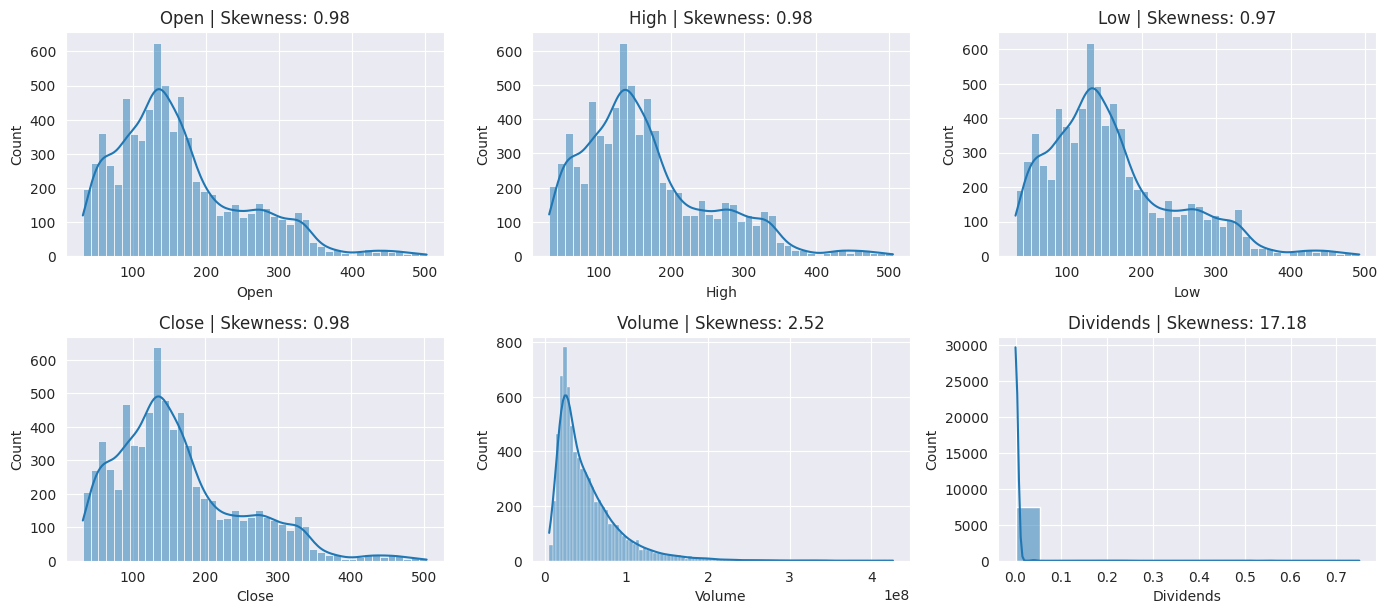

In [9]:
sns.set_style("darkgrid")

numerical_columns = data.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 3, idx)
    sns.histplot(data[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(data[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

Insight: The Dividends column is the column with the most skew in the dataframe follow by Volume, and the remains are 0,98 only low columns is 0.97.

A line plot is used as a visual method to show the distribution of numerical columns over time, based on the date column.

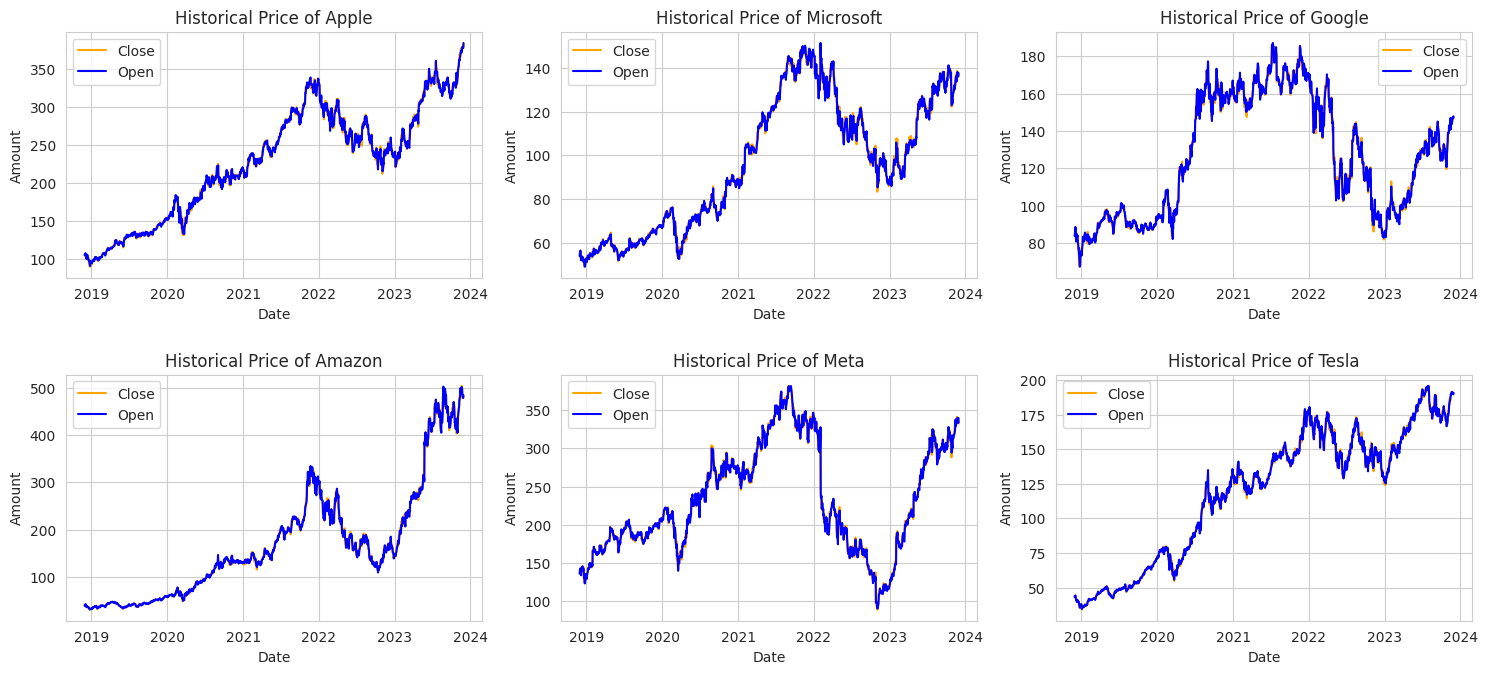

In [10]:
sns.set_style("whitegrid")

plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_name, 1):
    plt.subplot(3,3, i)
    company_data = data[data['company_name']== company_name[i - 6]]
    sns.lineplot(data= data, x='Date',y= company_data['Close'], label='Close', color='orange')
    sns.lineplot(data= data, x='Date',y= company_data['Open'], label='Open', color='blue')
    plt.legend()
    plt.ylabel('Amount')
    plt.title(f'Historical Price of {company}')

plt.tight_layout()
plt.show()

## Trading volume distribution

In [11]:
import plotly.graph_objs as go
import plotly.offline as pyo
from plotly.offline import init_notebook_mode, iplot, plot

# Assuming 'data' is a pandas DataFrame with 'Date', 'Volume', and 'company_name'

# Create a list of traces for each company
traces = []

for company in data['company_name'].unique():
    company_data = data[data['company_name'] == company]
    trace = go.Scatter(
        x=company_data['Date'],
        y=company_data['Volume'],
        mode='lines',
        name=company
    )
    traces.append(trace)

# Define layout
layout = go.Layout(
    title='Stock volume distribution of the top 6 companies',
    xaxis=dict(title='Date'),
    yaxis=dict(title='Volume')
)

# Create figure
fig = go.Figure(data=traces, layout=layout)

# Show the figure
fig.show(renderer='iframe') 



### Historical Open and Close prices different of the 6 selected companies

In [12]:
import plotly.graph_objs as go
import plotly.offline as pyo

# Compute the differences
data['diff_OpenClose'] = data['Open'] - data['Close']
data['diff_HighLow'] = data['High'] - data['Low']

# Group by year and company
Close_open = data.groupby(['Date', 'company_name'])['diff_OpenClose'].mean().reset_index()
High_low = data.groupby(['Date', 'company_name'])['diff_HighLow'].mean().reset_index()

# Pivot the data for display
pivot_open = Close_open.pivot_table(index='Date', columns='company_name', values='diff_OpenClose', aggfunc='mean')
pivot_High = High_low.pivot_table(index='Date', columns='company_name', values='diff_HighLow', aggfunc='mean')

# Create line chart for diff_OpenClose over time
traces = []

for company in Close_open['company_name'].unique():
    company_data = Close_open[Close_open['company_name'] == company]
    trace = go.Scatter(
        x=company_data['Date'],
        y=company_data['diff_OpenClose'],
        mode='lines+markers',
        name=company
    )
    traces.append(trace)

# Define layout
layout = go.Layout(
    title='Historical Open and Close Price Difference of the Selected Companies',
    xaxis=dict(title='Year'),
    yaxis=dict(title='Average (Open - Close) Price Difference'),
    hovermode='closest'
)

# Create and plot figure
fig = go.Figure(data=traces, layout=layout)
fig.show(renderer='iframe')

# Display pivot table
print("The Average difference of stock market between Open and Close distribution of each company")
pivot_open[:11]


The Average difference of stock market between Open and Close distribution of each company


company_name,Amazon,Apple,Google,Meta,Microsoft,Tesla
Date,,,,,,
2018-11-29 05:00:00+00:00,0.070999,0.746253,-0.552502,0.654931,0.132943,-2.759995
2018-11-30 05:00:00+00:00,-0.533501,0.410317,-0.700996,-1.409092,-0.180426,-2.350006
2018-12-03 05:00:00+00:00,-0.144997,-0.086383,0.790001,0.635088,0.864137,1.910004
2018-12-04 05:00:00+00:00,4.380005,1.022197,2.526001,2.761131,3.247628,2.800003
2018-12-06 05:00:00+00:00,-4.216003,-0.710262,-1.653999,-1.699346,-3.200145,-5.809998
2018-12-07 05:00:00+00:00,3.797005,1.199764,1.282501,2.691669,3.380564,1.830002
2018-12-10 05:00:00+00:00,-0.859497,-1.103784,-0.512001,-1.503364,-2.649369,-2.250000
2018-12-11 05:00:00+00:00,1.737999,0.727056,0.264500,1.828348,1.149019,1.800003
2018-12-12 05:00:00+00:00,0.272995,0.311936,0.167500,-0.119077,1.718768,-1.419998


### Historical High and Low prices different of the 6 top selected companies

In [13]:
# Group and sort volume data
volume_df = data.groupby(['company_name'])['Volume'].sum().reset_index().sort_values(by='Volume', ascending=False)

# Create bar trace
trace = go.Bar(
    x=volume_df['company_name'],
    y=volume_df['Volume'],
    marker=dict(color='skyblue')  # Optional: static color, or use dynamic if needed
)

# Define layout
layout = go.Layout(
    title='Stock Volume Distribution of the Top 6 Companies',
    xaxis=dict(title='Company'),
    yaxis=dict(title='Total Volume')
)

# Create figure
fig = go.Figure(data=[trace], layout=layout)

# Plot
fig.show(renderer='iframe')


**Insight:** Apple ranks first with the highest trading volume, followed by Amazon and Meta. Tesla has the lowest volume among the six companies.

In [14]:
import plotly.graph_objs as go
import plotly.offline as pyo

# Create a line trace for each company
traces = []

for company in data['company_name'].unique():
    company_data = data[data['company_name'] == company]
    trace = go.Scatter(
        x=company_data['Date'],
        y=company_data['Close'],
        mode='lines',
        name=company
    )
    traces.append(trace)

# Define layout
layout = go.Layout(
    title='Historical Close Prices of the Top 5 Companies',
    xaxis=dict(title='Date'),
    yaxis=dict(title='Close Price'),
    hovermode='closest'
)

# Create and display figure
fig = go.Figure(data=traces, layout=layout)
fig.show(renderer='iframe')


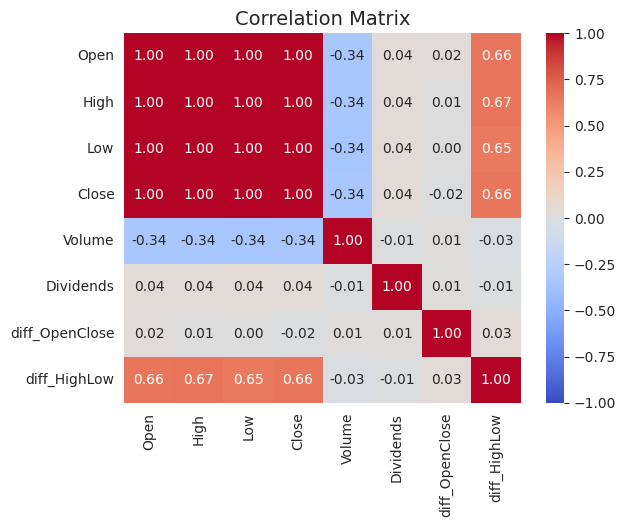

In [15]:
numerical_features = data.select_dtypes(include=['float64', 'int64'])

# Select numerical features
# Compute correlation matrix
corr_matrix = numerical_features.corr()

# Plot heatmap
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", annot_kws={"size": 10},
    cmap="coolwarm", vmin=-1, vmax=1
)

plt.title("Correlation Matrix", fontsize=14)
plt.show()

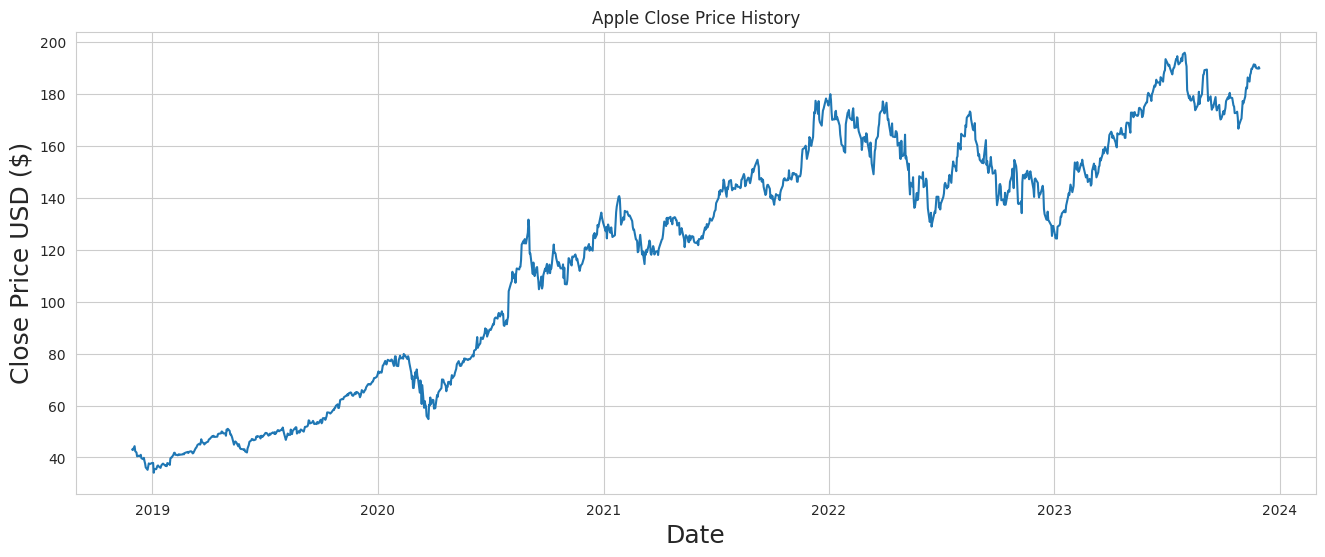

In [16]:
# Get the stock quote
df_select = data[data['company_name']== 'Apple']
# Show teh data
plt.figure(figsize=(16,6))
plt.title('Apple Close Price History')
plt.plot(df_select['Date'],df_select['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [17]:
# Create a new dataframe with only the 'Close column 
df_select.set_index(df_select['Date'], inplace = True)
df = df_select[['Close']].copy()
# Convert the dataframe to a numpy array
dataset = df.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

1196

# Scale the data

In [18]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.05540288],
       [0.05396443],
       [0.06321805],
       ...,
       [0.96207258],
       [0.96584248],
       [0.9626597 ]])

# Create the training data set

In [19]:
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()
        
# Convert the x_train and y_train to numpy arrays 
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.05540288, 0.05396443, 0.06321805, 0.05116168, 0.04824028,
       0.03900154, 0.0406476 , 0.03920912, 0.03990608, 0.04264951,
       0.03453779, 0.03225415, 0.03541274, 0.02773109, 0.02171032,
       0.01266435, 0.00688092, 0.02221453, 0.02070202, 0.02082065,
       0.02305982, 0.02332677, 0.        , 0.00900151, 0.00851215,
       0.01269406, 0.01649039, 0.01721705, 0.01497779, 0.01158184,
       0.01613447, 0.0189076 , 0.02027184, 0.02169554, 0.01647553,
       0.01739495, 0.01558573, 0.02308948, 0.02092438, 0.01852205,
       0.03419677, 0.03596146, 0.03608016, 0.04309445, 0.0474395 ,
       0.04752845, 0.0426347 , 0.0429326 , 0.04147309, 0.04364748,
       0.04259003, 0.04351338, 0.0429475 , 0.04370701, 0.04534524,
       0.04390063, 0.04674518, 0.04862176, 0.04877068, 0.04957494])]
[0.047013300180601875]

[array([0.05540288, 0.05396443, 0.06321805, 0.05116168, 0.04824028,
       0.03900154, 0.0406476 , 0.03920912, 0.03990608, 0.04264951,
       0.03453779, 0.03225415, 0.0

# LSTM Model Training

In [20]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

Model = Sequential()

Model = Sequential()
Model.add(LSTM(units=128, return_sequences=True, input_shape=(x_train.shape[1], 1)))
Model.add(LSTM(units=64, return_sequences=True))
Model.add(LSTM(units=32))
Model.add(Dense(1))  # Predicting the next 'Close' price
#Output layer
Model.add(Dense(units=1))

I0000 00:00:1760090674.215297      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1760090674.215966      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [21]:
Model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,419 (501.64 KB)

 Trainable params: 128,419 (501.64 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow import keras

# Define optimizer (you named it "rmsprop" but used Adam — better to rename for clarity)
adam = keras.optimizers.Adam(learning_rate=0.0001)

# Compile the model (assumes 'model' is your LSTM model)
Model.compile(optimizer=adam, loss='mean_squared_error')

#fit the model
Model.fit(x_train,y_train, epochs=2, batch_size=1, verbose=1)

Epoch 1/2


I0000 00:00:1760090679.754659      67 cuda_dnn.cc:529] Loaded cuDNN version 90300


1136/1136 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 0.0219
Epoch 2/2
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0020


# LSTM Model Evaluation

In [23]:
# Create the testing data set

test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values 
predictions = Model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))


from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print('Root Mean_squared_error', rmse)
print("Mean_absolute_error:", mae)
print("Mean_squared_error:", mse)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
Root Mean_squared_error 6.359929837317027
Mean_absolute_error: 5.485135724467547
Mean_squared_error: 40.448707535595396


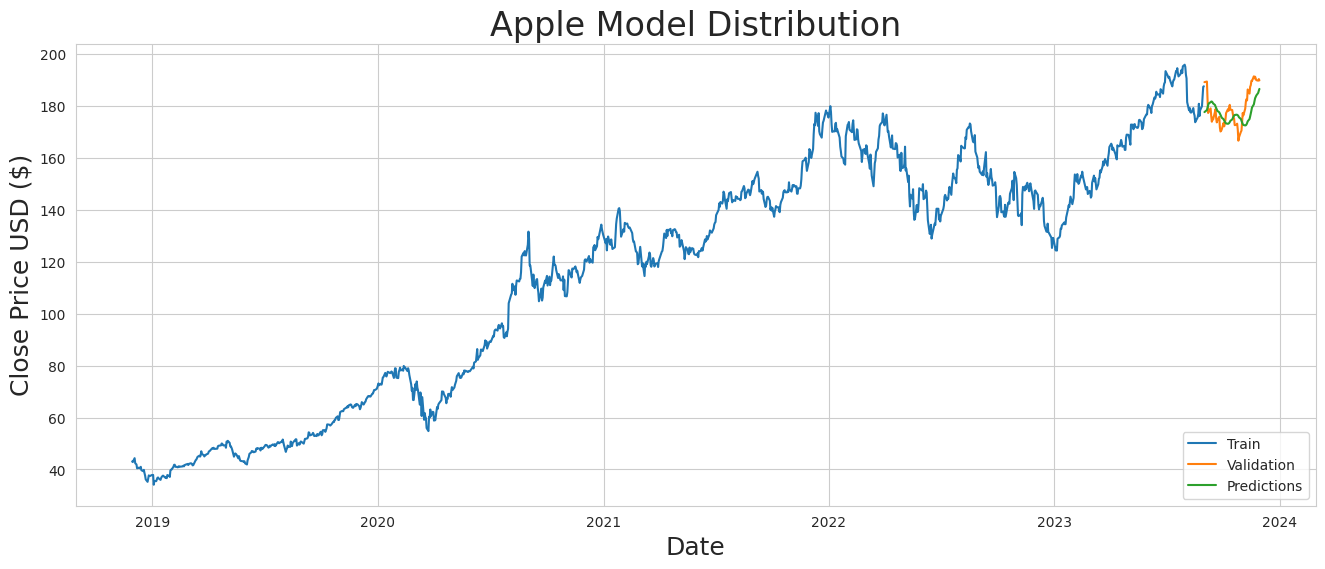

In [24]:
# Plot the data
train = df[:training_data_len]
valid = df[training_data_len:]
valid['Predictions'] = predictions
valid['predict_diff'] = valid['Close'] - valid['Predictions']

#Visualized

# First plot: Model distribution for Apple
plt.figure(figsize=(16,6))
plt.title('Apple Model Distribution', fontsize=24)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Validation', 'Predictions'], loc='lower right')
plt.show()


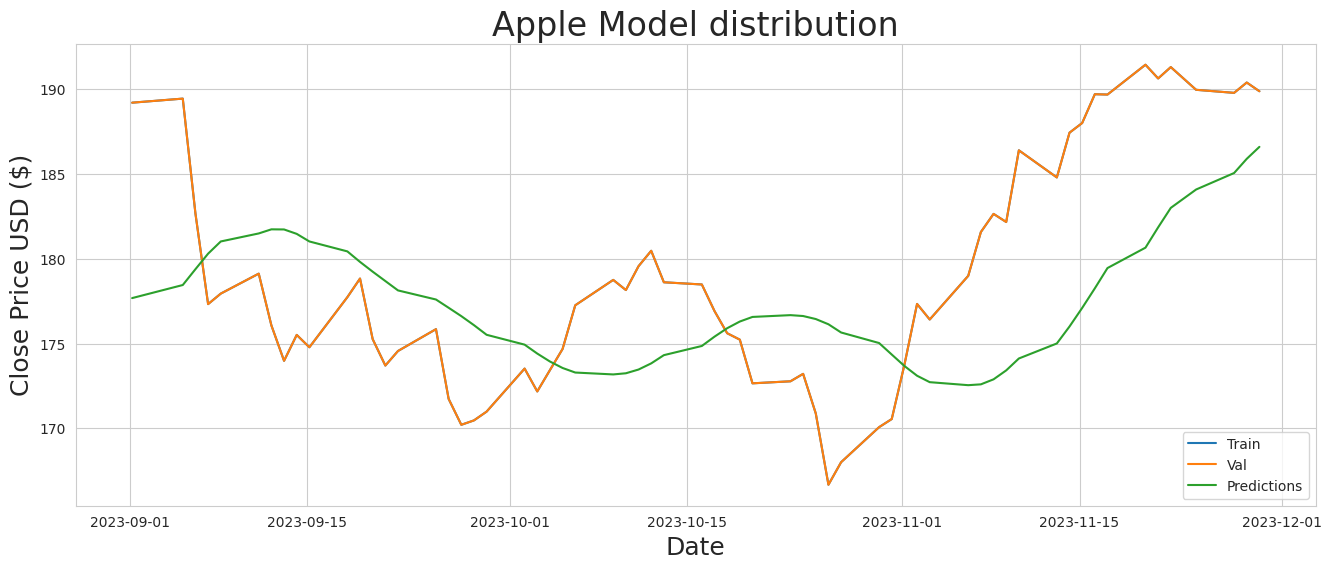

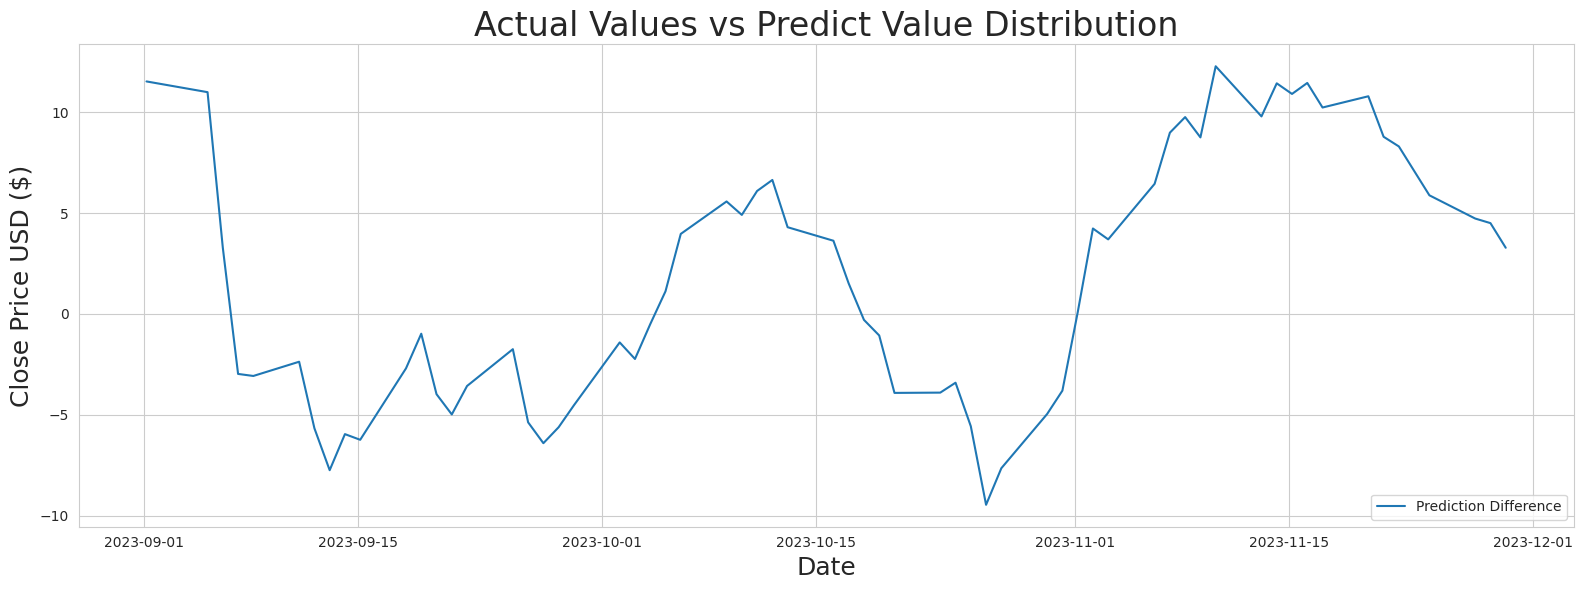

In [25]:
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Apple Model distribution', fontsize=24)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(valid['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')

# Second plot: Difference value distribution
plt.figure(figsize=(16,6))
plt.title('Actual Values vs Predict Value Distribution', fontsize=24)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(valid['predict_diff'])
plt.legend(['Prediction Difference'], loc='lower right')

# Fixed typo here: was `tightloyout()` instead of `tight_layout()`
plt.tight_layout()
plt.show()

In [26]:
valid

,Close,Predictions,predict_diff
Date,,,
2023-09-01 04:00:00+00:00,189.210739,177.681427,11.529312
2023-09-05 04:00:00+00:00,189.450409,178.452988,10.997421
2023-09-06 04:00:00+00:00,182.669342,179.386688,3.282654
2023-09-07 04:00:00+00:00,177.326385,180.302551,-2.976166
2023-09-08 04:00:00+00:00,177.945557,181.022827,-3.077271
...,...,...,...
2023-11-22 05:00:00+00:00,191.309998,183.004715,8.305283
2023-11-24 05:00:00+00:00,189.970001,184.088058,5.881943
2023-11-27 05:00:00+00:00,189.789993,185.060104,4.729889


## Summary

In this notebook project, we perform an in-depth **exploratory data analysis (EDA)** and **predictive modeling** using Apple stock market data. The main objective is to gain insights into historical stock performance and build a model to predict future prices.

We focus specifically on the **closing price** (`Close` column) of **The 5 companies**, analyzing its historical trends, patterns, and behaviors. Through this process, we aim to:

* Understand how Apple’s stock price has evolved over time
* Identify any seasonal patterns or anomalies in its performance
* Create and train a model to **predict future closing prices**
* Evaluate the model's accuracy and visualize the predictions compared to actual values

This project involves key steps such as data cleaning, visualization, and time series modeling.

